In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:\\Users\\Hassan\\Downloads\\archive (5).zip")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                25 non-null     int64  
 1   PerFemEmploy        25 non-null     float64
 2   FertilityRate       25 non-null     object 
 3   Ratio_MaletoFemale  25 non-null     float64
 4   PerFemEmployers     25 non-null     float64
 5   Agriculture         25 non-null     float64
 6   Industry            25 non-null     float64
 7   Services            25 non-null     float64
 8   Wage&Salaried       25 non-null     float64
 9   ContrFamWorkers     25 non-null     float64
 10  OwnAccount          25 non-null     float64
 11  Vulnerable          25 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 2.5+ KB


In [4]:
df.head()

,Year,PerFemEmploy,FertilityRate,Ratio_MaletoFemale,PerFemEmployers,Agriculture,Industry,Services,Wage&Salaried,ContrFamWorkers,OwnAccount,Vulnerable
0,1995,24.30,3.71,28.33,0.1,84.79,7.66,7.56,18.03,66.80,15.07,81.87
1,1996,24.57,3.59,28.72,0.1,82.28,7.46,10.27,18.38,66.39,15.14,81.52
2,1997,24.82,3.48,29.18,0.1,81.19,7.57,11.24,18.74,65.95,15.21,81.16
3,1998,25.11,3.37,29.67,0.1,80.28,7.77,11.95,19.11,65.53,15.26,80.79
4,1999,25.38,3.27,30.17,0.1,79.52,8.12,12.36,19.50,65.01,15.39,80.40


In [5]:
df["FertilityRate"] = df['FertilityRate'].replace("-",np.nan)

In [6]:
df["FertilityRate"] =  pd.to_numeric(df['FertilityRate'])

In [7]:
df["FertilityRate"] 

0     3.71
1     3.59
2     3.48
3     3.37
4     3.27
5     3.17
6     3.07
7     2.97
8     2.88
9     2.78
10    2.69
11    2.60
12    2.52
13    2.45
14    2.38
15    2.32
16    2.27
17    2.23
18    2.19
19    2.15
20    2.12
21    2.09
22    2.06
23     NaN
24     NaN
Name: FertilityRate, dtype: float64

In [8]:
pd.isnull(df)

,Year,PerFemEmploy,FertilityRate,Ratio_MaletoFemale,PerFemEmployers,Agriculture,Industry,Services,Wage&Salaried,ContrFamWorkers,OwnAccount,Vulnerable
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
mean_value=df["FertilityRate"].mean()

In [10]:
df["FertilityRate"].fillna(mean_value,inplace = True)

In [11]:
print(df["FertilityRate"].isna().sum())

0


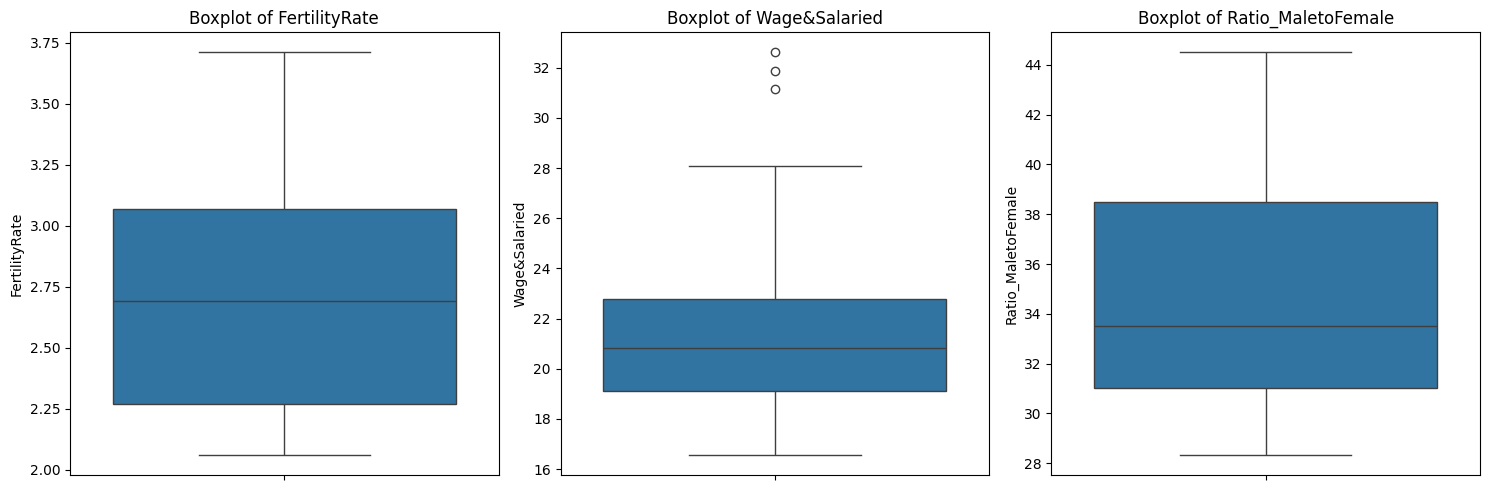

In [12]:
features = ["FertilityRate", "Wage&Salaried", "Ratio_MaletoFemale"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  
for i, feature in enumerate(features):
    sns.boxplot(y=df[feature], ax=axes[i])  
    axes[i].set_title(f"Boxplot of {feature}") 
plt.tight_layout() 
plt.show()

In [13]:
Q1 = df['Wage&Salaried'].quantile(0.25)
Q3 = df['Wage&Salaried'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Wage&Salaried'] < lower_bound) | (df['Wage&Salaried'] > upper_bound)]
print(outliers[['Wage&Salaried']])

    Wage&Salaried
22          31.17
23          31.89
24          32.61


In [14]:
df_filtered = df[(df['Wage&Salaried'] >= lower_bound) & (df['Wage&Salaried'] <= upper_bound)]
print(df_filtered[['Wage&Salaried']])

    Wage&Salaried
0           18.03
1           18.38
2           18.74
3           19.11
4           19.50
5           19.90
6           20.31
7           20.81
8           21.31
9           21.73
10          22.18
11          22.78
12          21.08
13          19.45
14          17.89
15          16.56
16          17.98
17          19.47
18          21.03
19          23.39
20          25.74
21          28.09


In [15]:
df_filtered.to_csv('C:\\Users\\Hassan\\Downloads\\filtered_data.csv',index=False)

# Dataset Documentation

## 1. Dataset Source

The dataset used for this study was sourced from the World Bank databank. It covers data collected from a population survey in Bangladesh, spanning from 1995 to 2019. The data includes various socioeconomic factors related to female employment.

## 2. Features Used

- **PerFemEmploy**: Employment-to-population ratio (%) of women aged 15 or older.
- **FertilityRate**: The total fertility rate, representing the number of children a woman is expected to have.
- **Ratio_MaletoFemale**: The ratio of female to male labor force participation rates.
- **PerFemEmployers**: The percentage of female workers who are employers.
- **Agriculture**: Percentage of female workers in agriculture.
- **Industry**: Percentage of female workers in the industrial sector.
- **Services**: Percentage of female workers in the services sector.
- **Wage&Salaried**: Percentage of female workers who are wage and salaried employees.
- **ContrFamWorkers**: Percentage of female workers who are contributing family workers.
- **OwnAccount**: Percentage of female workers who are own-account workers.
- **Vulnerable**: Percentage of female workers in vulnerable employment (own-account + contributing family workers).

## 3. Preprocessing Steps

- **Handling Missing Data**: Missing values in the **FertilityRate** column were handled by using mean imputation.
- **Outlier Detection**: Outliers in the **Wage&Salaried** column were identified using the IQR method and removed from the dataset.

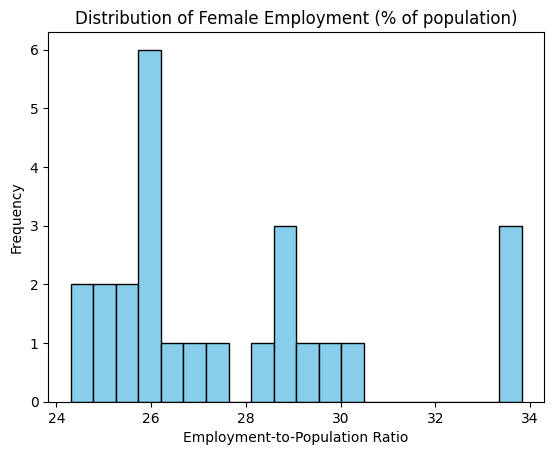

In [16]:
plt.hist(df['PerFemEmploy'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Female Employment (% of population)')
plt.xlabel('Employment-to-Population Ratio')
plt.ylabel('Frequency')
plt.show()


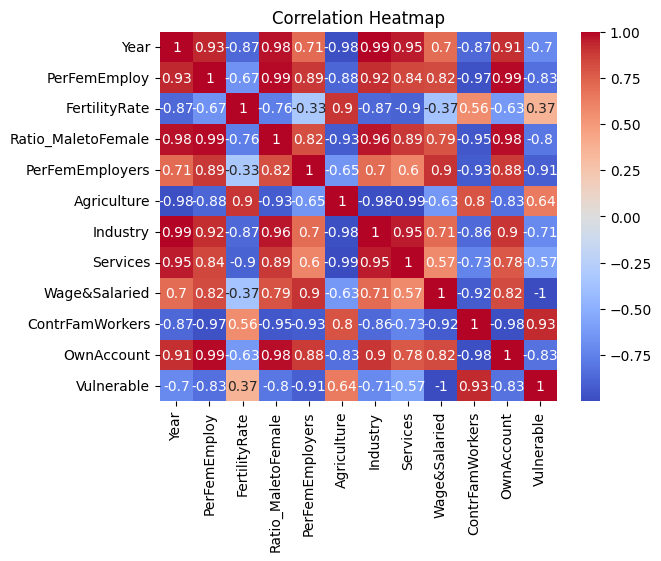

In [17]:
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [18]:
df = pd.read_csv("C:\\Users\\Hassan\\Downloads\\Ids project\\cleaned_dataset.csv") # loading dataset
X=df[["FertilityRate", "Wage&Salaried", "Ratio_MaletoFemale"]]        # independent variables
Y=df[["PerFemEmploy"]] 

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=42) # splitting data into training and testing data
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((15, 3), (7, 3), (15, 1), (7, 1))

In [21]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()                 # building linearRefression model

## Independent Variables (Features)
- **FertilityRate**  
- **Wage&Salaried**  
- **Ratio_MaletoFemale**  

## Target (Dependent Variable)
- **PerFemEmploy**    

In [22]:
linear_model.fit(x_train,y_train)           # training the model with training data 
print("c_0  = " , linear_model.intercept_)  # Y-intercept 
print("c_{1,3} = " , linear_model.coef_)    # coefficients (slopes)

c_0  =  [4.84213246]
c_{1,3} =  [[ 0.99120411 -0.0473777   0.60223778]]


In [23]:
y_train_pred = linear_model.predict(x_train)  # model prediction on training data
y_test_pred = linear_model.predict(x_test)    # model prediction on test data 

In [24]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
mean_absolute_error(y_train , y_train_pred ) # MAE for model evaluation purpose

0.13211624972882016

In [25]:
mean_absolute_error(y_test , y_test_pred)

0.21901789432200708

In [26]:
mean_squared_error(y_train,y_train_pred )  # MSE for model evaluation purpose

0.025774009804850156

In [27]:
mean_squared_error(y_test,y_test_pred)

0.08501657905140533

In [28]:
r2_score(y_train,y_train_pred)            #r2_score for moddel evaluation purpose

0.9915880754182842

In [29]:
r2_score(y_test,y_test_pred)

0.9771510698590122

In [30]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(linear_model , X , Y , cv=4)    # cross validation taking 4 folds 
scores                                                   #r2_score for each fold 

array([-0.67250807, -1.76926743,  0.84155366, -4.65197812])

In [31]:
np.mean(scores)                                          #mean of all r2_score values

np.float64(-1.5630499911767788)

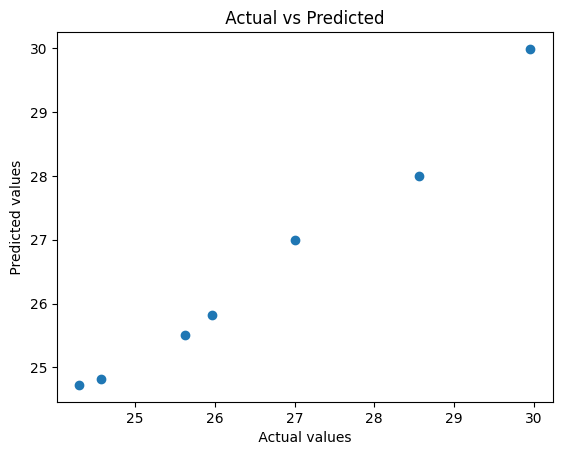

In [32]:
# Scatter plot of Actual vs Predicted 
plt.scatter(y_test , y_test_pred)
plt.xlabel(" Actual values ")
plt.ylabel(" Predicted values ")
plt.title(" Actual vs Predicted ")
plt.show()

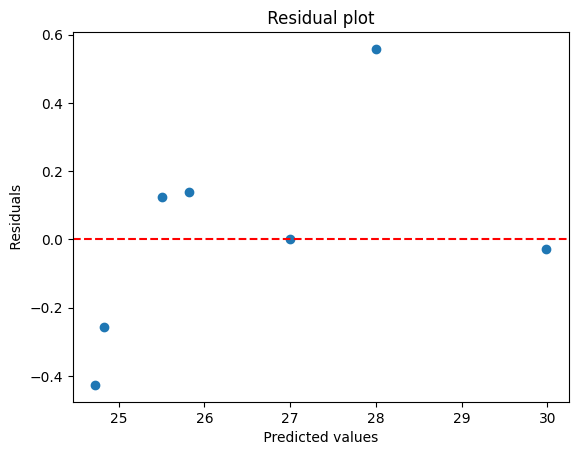

In [33]:
#Residual plot 
residuals = y_test - y_test_pred
plt.scatter(y_test_pred , residuals)
plt.axhline(y=0 ,color='r' ,linestyle='--' )
plt.xlabel(" Predicted values ")
plt.ylabel(" Residuals ")
plt.title(" Residual plot ")
plt.show()

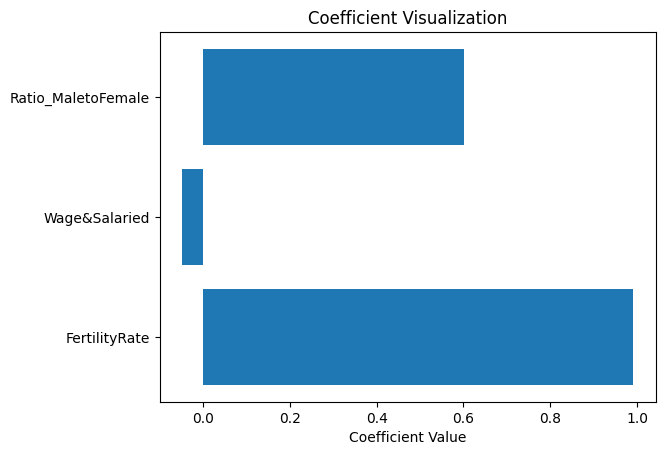

In [34]:
coef = linear_model.coef_
# Plot coefficients
coef = coef.flatten()
plt.barh(x_train.columns, coef)
plt.xlabel('Coefficient Value')
plt.title('Coefficient Visualization')
plt.show()